# Compute metrics for different runs and plot them
##### author: Elizabeth A. Barnes, Randal J. Barnes and Mark DeMaria
##### version: v0.2.0

In [1]:
%matplotlib inline
%load_ext autotime
import os

import experiment_settings
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

dpiFig = 400
plt.style.use("seaborn-white")
mpl.rcParams["figure.dpi"] = 100
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

time: 3.59 s (started: 2023-11-27 12:09:36 -07:00)


In [ ]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "4 November 2022"

In [2]:
testing = experiment_settings.Experiments()
print('index range and short names for experiments')
for expname in testing.get_exp_list_short:
    exp_inds = [index for index, exp_string in enumerate(testing.get_exp_list) if expname in exp_string]
    print(np.min(exp_inds), '-', np.max(exp_inds)+1, expname)

index range and short names for experiments
0 - 20 dev_OFD
20 - 40 dev_OBD
time: 3.81 ms (started: 2023-11-27 12:09:42 -07:00)


In [3]:
# pick the experiment
expname = 'dev_OBD'

# get the correct indices for these experiments
exp_inds = [index for index, exp_string in enumerate(testing.get_exp_list) if expname in exp_string]

time: 446 µs (started: 2023-11-27 12:09:48 -07:00)


In [4]:
EXP_NAME_LIST = testing.get_exp_list[np.min(exp_inds):np.max(exp_inds)+1]
EXP_NAME_LIST

['dev_OBD_AL12',
 'dev_OBD_AL24',
 'dev_OBD_AL36',
 'dev_OBD_AL48',
 'dev_OBD_AL60',
 'dev_OBD_AL72',
 'dev_OBD_AL84',
 'dev_OBD_AL96',
 'dev_OBD_AL108',
 'dev_OBD_AL120',
 'dev_OBD_EP12',
 'dev_OBD_EP24',
 'dev_OBD_EP36',
 'dev_OBD_EP48',
 'dev_OBD_EP60',
 'dev_OBD_EP72',
 'dev_OBD_EP84',
 'dev_OBD_EP96',
 'dev_OBD_EP108',
 'dev_OBD_EP120']

time: 1.55 ms (started: 2023-11-27 12:09:56 -07:00)


In [5]:
APPEND_NAME = ''
DATA_PATH = "data/"
MODEL_PATH = os.path.join("saved_models", expname)
FIGURE_PATH = os.path.join("figures/analysis/", expname)
METRICS_PATH = os.path.join("saved_metrics/", expname)
PREDICTIONS_PATH = os.path.join("saved_predictions/", expname)

if not os.path.exists(FIGURE_PATH):
    os.makedirs(FIGURE_PATH)

time: 1.36 ms (started: 2023-11-27 12:12:21 -07:00)


## Plotting functions

In [6]:
FS = 16

### for white background...
plt.rc('text', usetex=True)
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Avant Garde']})
plt.rc('savefig', facecolor='white')
plt.rc('axes', facecolor='white')
plt.rc('axes', labelcolor='dimgrey')
plt.rc('axes', labelcolor='dimgrey')
plt.rc('xtick', color='dimgrey')
plt.rc('ytick', color='dimgrey')


################################
################################  
def adjust_spines(ax, spines):
    for loc, spine in ax.spines.items():
        if loc in spines:
            spine.set_position(('outward', 5))
        else:
            spine.set_color('none')
    if 'left' in spines:
        ax.yaxis.set_ticks_position('left')
    else:
        ax.yaxis.set_ticks([])
    if 'bottom' in spines:
        ax.xaxis.set_ticks_position('bottom')
    else:
        ax.xaxis.set_ticks([])


def format_spines(ax):
    adjust_spines(ax, ['left', 'bottom'])
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
    ax.spines['left'].set_color('dimgrey')
    ax.spines['bottom'].set_color('dimgrey')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params('both', length=4, width=2, which='major', color='dimgrey')

#     ax.yaxis.grid(zorder=1,color='dimgrey',alpha=0.35)


time: 1.31 ms (started: 2023-11-27 12:12:28 -07:00)


## Get the dataframe

In [7]:
df_metrics = pd.DataFrame()

for exp_name in EXP_NAME_LIST:
    print(exp_name)
    settings = experiment_settings.get_settings(exp_name.split("_datasubset")[0])

    # set testing data
    if settings["test_condition"] == "leave-one-out":
        TESTING_YEARS_LIST = np.arange(2013, 2023)
    elif settings["test_condition"] == "years":
        TESTING_YEARS_LIST = (np.copy(settings["years_test"]))
    else:
        raise NotImplementedError('no such testing condition')

    for testing_years in TESTING_YEARS_LIST:
        # set testing year
        settings["years_test"] = (testing_years,)

        for rng_seed in settings["rng_seed_list"]:
            settings['rng_seed'] = rng_seed

            model_name = (
                    exp_name + "_" +
                    str(testing_years)
            )

            # load the metric filename
            metric_filename = os.path.join(METRICS_PATH, model_name + '_metrics.pickle')
            if not os.path.exists(metric_filename):
                metric_filename = os.path.join(METRICS_PATH, model_name + '_metrics.pkl')
                if not os.path.exists(metric_filename):
                    print(metric_filename + ' DOES NOT exist. Skipping...')
                    continue

            # pprint.pprint(model_name)
            df = pd.read_pickle(metric_filename)
            df_metrics = pd.concat([df_metrics, df])

# get best validation results            
idx = df_metrics.groupby(['exp_name', 'testing_years'], sort=False)['pit_D_valtest'].transform(min) == df_metrics['pit_D_valtest']
df_metrics_bestval = df_metrics[idx]

BEST_VAL_ONLY = True
if BEST_VAL_ONLY:
    print("**plotting only the best seed based on smallest pit_D**")
    df_metrics = df_metrics[idx]
    df_bestval = df_metrics[["exp_name", "basin_lead", "testing_years", "rng_seed"]]
    df_bestval.to_pickle(os.path.join(METRICS_PATH, expname + "_best_validation_metrics.pickle"))
else:
    APPEND_NAME = APPEND_NAME + "_allNetworks"

dev_OBD_AL12
dev_OBD_AL24
dev_OBD_AL36
dev_OBD_AL48
dev_OBD_AL60
dev_OBD_AL72
dev_OBD_AL84
dev_OBD_AL96
dev_OBD_AL108
dev_OBD_AL120
dev_OBD_EP12
dev_OBD_EP24
dev_OBD_EP36
dev_OBD_EP48
dev_OBD_EP60
dev_OBD_EP72
dev_OBD_EP84
dev_OBD_EP96
dev_OBD_EP108
dev_OBD_EP120
**plotting only the best seed based on smallest pit_D**
time: 36.3 ms (started: 2023-11-27 12:14:52 -07:00)


## Main figure

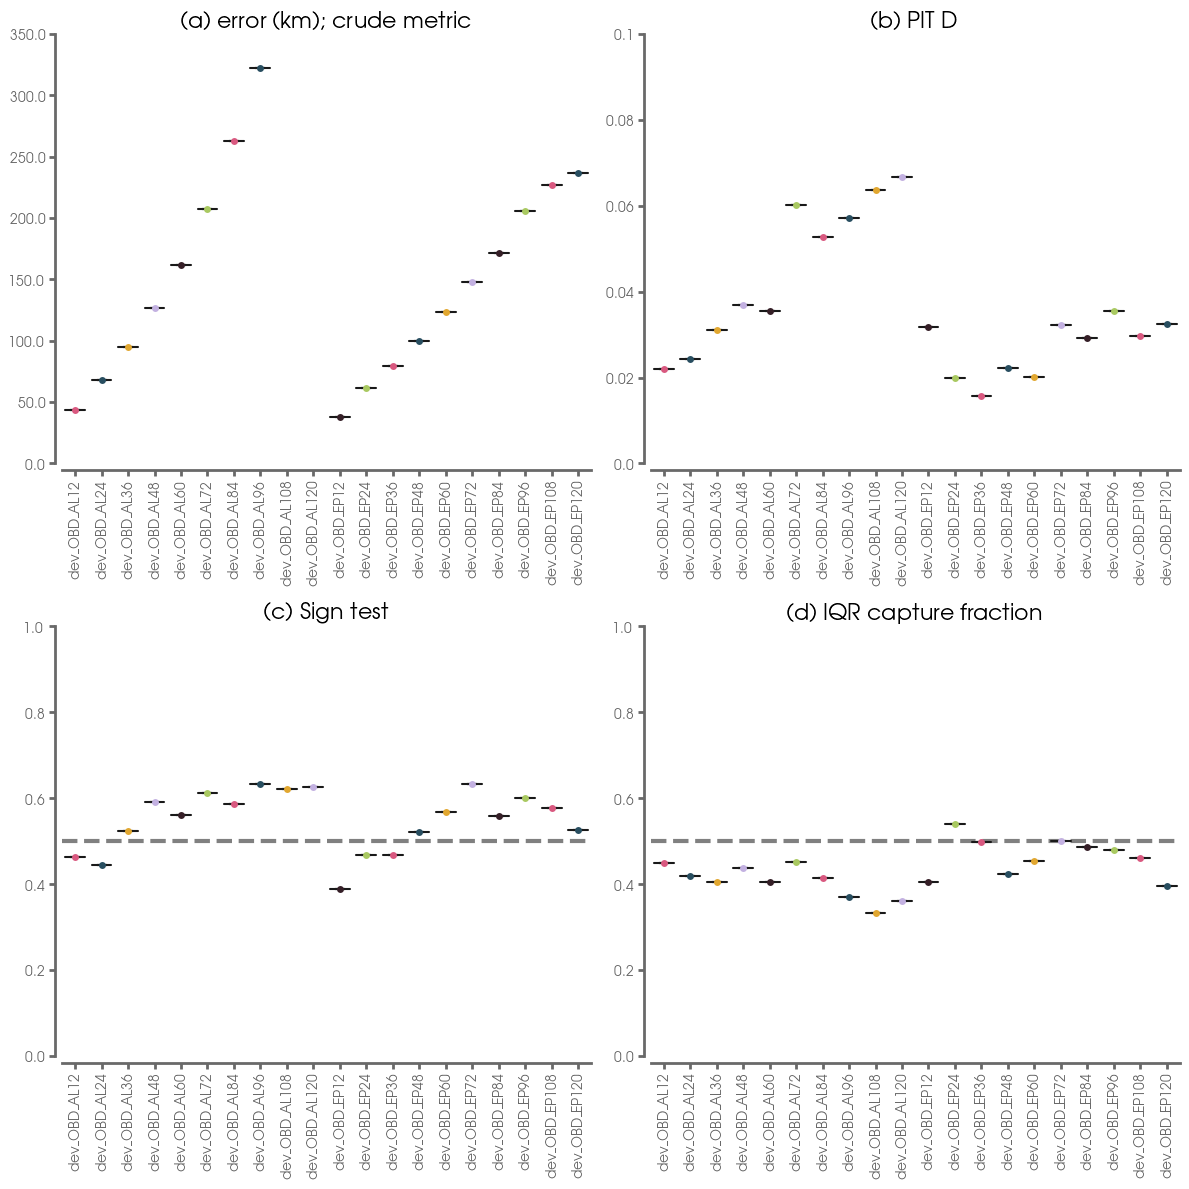

time: 12.6 s (started: 2023-11-27 12:15:43 -07:00)


In [8]:
FS_A = 10
colors = ('#D95980', '#284E60', '#E1A730', '#C3B1E1', '#351F27', '#A9C961')
panel_letters = ('(a)', '(b)', '(c)', '(d)')
x_axis_list = ("exp_name",)  #("basin_lead", "exp_name")

metric_data = ''
metric_list = ('mean_error_test',
               'pit_D_valtest',
               'sign_test_valtest',
               'iqr_capture_valtest',
               )
title_text = ('(a) error (km); crude metric',
              '(b) PIT D',
              '(c) Sign test',
              '(d) IQR capture fraction',
              )

for x_axis in x_axis_list:
    f, axs = plt.subplots(2, 2, figsize=(15 / 1.25, 1.5*10 / 1.25))
    axs = axs.flatten()

    for imetric, metric in enumerate([m + metric_data for m in metric_list]):
        ax = axs[imetric]
        g1 = sns.boxplot(x=x_axis,
                         y=metric,
                         hue="basin_lead",
                         data=df_metrics,
                         palette=colors,
                         width=.75,
                         dodge=False,
                         boxprops={'alpha': .2,
                                   'edgecolor': 'white',
                                   },
                         fliersize=0,
                         ax=ax)
        g2 = sns.swarmplot(x=x_axis,
                           y=metric,
                           hue="basin_lead",
                           palette=colors,
                           data=df_metrics,
                           dodge=False,
                           size=5,
                           ax=ax)

        if metric.find('iqr_capture') > -1:
            ax.axhline(y=0.5, linewidth=3, linestyle='--', color='gray')
            ax.set_ylim(0, 1.0)
        if metric.find('sign') > -1:
            ax.axhline(y=0.5, linewidth=3, linestyle='--', color='gray')
            ax.set_ylim(0, 1.0)
        if metric.find('pit_D') > -1:
            ax.set_ylim(0, .1)
        # if metric.find('reduction') > -1:
        #     ax.axhline(y=0.0, linewidth=3, linestyle='--', color='gray')
        #     ax.set_ylim(-4.5, 4.5)
        if metric.find('reduction') == -1 and metric.find('n_error') > -1:
            ax.set_ylim(0., 350.)
        if metric.find('iqr_error') > -1:
            ax.set_ylim(-.3, 1.)
            ax.axhline(y=0.0, linewidth=3, linestyle='--', color='gray')

        ax.set_title(title_text[imetric],
                     fontsize=FS,
                     color='k',
                     )

        ax.get_legend().remove()
        x_tick_labels = ax.get_xticklabels()
        yticks = np.around(ax.get_yticks(), 3)
        ax.set_yticklabels(yticks)
        ax.set_ylabel('')

        format_spines(ax)
        ax.set_xticklabels(x_tick_labels, rotation=90)
        ax.set_xlabel('')

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_PATH, expname + '_comparisonsMetrics' + APPEND_NAME + '.png'), dpi=dpiFig)
    # plt.close()
    plt.show()

time: 7.29 s (started: 2022-12-16 05:36:27 -07:00)
